# Long rectangles 

Searching for best peak across 100 slices...
Ignoring 30 voxels at Top/Bottom of Axis 0.
Winner Found! Shift: 79 px | Score: 0.8015


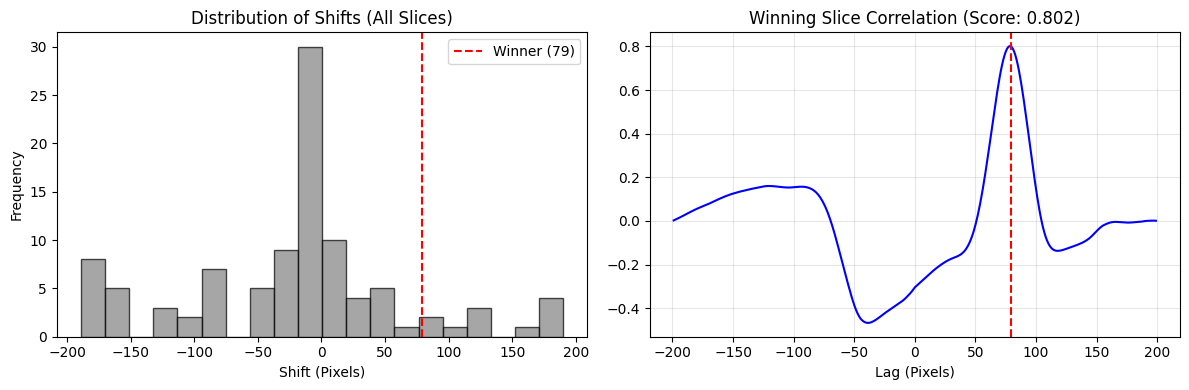

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags
from pathlib import Path
import napari

# ==========================================
# 1. DISCRETIZED TFM STITCHER CLASS
# ==========================================
class TFMStitcher:
    def __init__(self, vol1, vol2, axis=2):
        self.vol1 = vol1.astype(np.float32)
        self.vol2 = vol2.astype(np.float32)
        self.axis = axis
        self.shift_index = None
        self.correlation_curve = None
        self.lags = None
        self.all_shifts = []  # To track the "votes" of all slices
        self.best_score = 0   # Strength of the winning peak

    def find_optimal_shift(self, num_slices=30, method='max', ignore_z=20):
        """
        Discretizes the volume into slices. The slice with the highest 
        normalized correlation peak determines the final shift.
        """
        # 1. Handle Depth Axis Cropping (Axis 0)
        z_limit = self.vol1.shape[0]
        z_start = ignore_z
        z_end = z_limit - ignore_z
        
        # 2. Determine Discretization Axis (usually Axis 1 if Scan is 2)
        slice_axis = 0 
        dim_size = self.vol1.shape[slice_axis]
        indices = np.linspace(0, dim_size, num_slices + 1).astype(int)
        
        self.all_shifts = []
        self.best_score = -1
        winner_curve = None
        winner_lags = None

        print(f"Searching for best peak across {num_slices} slices...")
        print(f"Ignoring {ignore_z} voxels at Top/Bottom of Axis 0.")

        for i in range(num_slices):
            idx_start, idx_end = indices[i], indices[i+1]
            
            # Extract sub-volumes with Z-crop and Slice-crop
            sl = [slice(None)] * 3
            sl[0] = slice(z_start, z_end) 
            sl[slice_axis] = slice(idx_start, idx_end)
            
            sub_v1 = self.vol1[tuple(sl)]
            sub_v2 = self.vol2[tuple(sl)]
            
            # Project to 1D along the scan axis
            collapse_axes = tuple([ax for ax in range(3) if ax != self.axis])
            
            if method == 'max':
                sig1 = np.max(sub_v1, axis=collapse_axes)
                sig2 = np.max(sub_v2, axis=collapse_axes)
            else:
                sig1 = np.mean(sub_v1, axis=collapse_axes)
                sig2 = np.mean(sub_v2, axis=collapse_axes)

            # Skip silent/empty slices
            if np.std(sig1) < 1e-6 or np.std(sig2) < 1e-6:
                continue

            # Normalize signals for true Cross-Correlation Coefficient calculation
            sig1_norm = (sig1 - np.mean(sig1))
            sig2_norm = (sig2 - np.mean(sig2))
            
            corr = correlate(sig1_norm, sig2_norm, mode='full', method='fft')
            lags = correlation_lags(len(sig1), len(sig2), mode='full')
            
            # Calculate peak confidence score (normalized correlation coefficient)
            # This ensures we pick the 'best' match regardless of signal magnitude
            denom = np.sqrt(np.sum(sig1_norm**2) * np.sum(sig2_norm**2))
            norm_corr = corr / (denom + 1e-10)
            
            peak_idx = np.argmax(norm_corr)
            peak_score = norm_corr[peak_idx]
            peak_shift = lags[peak_idx]
            
            self.all_shifts.append(peak_shift)

            # --- WINNER TAKES ALL LOGIC ---
            if peak_score > self.best_score:
                self.best_score = peak_score
                self.shift_index = peak_shift
                winner_curve = norm_corr
                winner_lags = lags

        if self.shift_index is None:
            raise ValueError("No valid features found in any slices. Check your ignore_z or data.")

        self.correlation_curve = winner_curve
        self.lags = winner_lags
        
        print(f"Winner Found! Shift: {self.shift_index} px | Score: {self.best_score:.4f}")
        return self.shift_index

    def plot_diagnostic(self):
        """Visualizes the distribution of votes and the winning curve."""
        plt.figure(figsize=(12, 4))
        
        # Plot 1: Histogram of all slices
        plt.subplot(1, 2, 1)
        plt.hist(self.all_shifts, bins=20, color='gray', alpha=0.7, edgecolor='black')
        plt.axvline(self.shift_index, color='red', linestyle='--', label=f'Winner ({self.shift_index})')
        plt.title("Distribution of Shifts (All Slices)")
        plt.xlabel("Shift (Pixels)")
        plt.ylabel("Frequency")
        plt.legend()

        # Plot 2: The winning correlation curve
        plt.subplot(1, 2, 2)
        plt.plot(self.lags, self.correlation_curve, color='blue')
        plt.axvline(self.shift_index, color='red', linestyle='--')
        plt.title(f"Winning Slice Correlation (Score: {self.best_score:.3f})")
        plt.xlabel("Lag (Pixels)")
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

    def stitch(self, blend_mode='linear'):
        if self.shift_index is None:
            raise RuntimeError("Run find_optimal_shift() first.")

        shift = int(round(self.shift_index))
        s1, s2 = self.vol1.shape, self.vol2.shape
        L1, L2 = s1[self.axis], s2[self.axis]

        # Calculate coordinate offsets
        v1_start, v2_start = (abs(shift), 0) if shift < 0 else (0, shift)
        total_len = max(v1_start + L1, v2_start + L2)
        
        out_shape = list(s1)
        out_shape[self.axis] = total_len
        stitched = np.zeros(out_shape, dtype=np.float32)

        def get_slice_idx(start, length):
            sl = [slice(None)] * 3
            sl[self.axis] = slice(int(start), int(start + length))
            return tuple(sl)

        inter_start = max(v1_start, v2_start)
        inter_end = min(v1_start + L1, v2_start + L2)
        overlap_len = inter_end - inter_start

        # Fill Volume 1
        stitched[get_slice_idx(v1_start, L1)] = self.vol1
        
        # Blending in overlap
        if overlap_len > 0:
            idx1_overlap = inter_start - v1_start
            idx2_overlap = inter_start - v2_start
            chunk1 = self.vol1[get_slice_idx(idx1_overlap, overlap_len)]
            chunk2 = self.vol2[get_slice_idx(idx2_overlap, overlap_len)]

            if blend_mode == 'linear':
                ramp = np.linspace(0, 1, overlap_len)
                ramp_shape = [1, 1, 1]
                ramp_shape[self.axis] = overlap_len
                w2 = ramp.reshape(ramp_shape)
                if shift < 0: w2 = 1.0 - w2 # Flip for negative shifts
                
                stitched[get_slice_idx(inter_start, overlap_len)] = (chunk1 * (1.0 - w2)) + (chunk2 * w2)
            else:
                mid = overlap_len // 2
                stitched[get_slice_idx(inter_start + mid, overlap_len - mid)] = chunk2[get_slice_idx(mid, overlap_len - mid)]

        # Fill remaining Volume 2
        post_len = (v2_start + L2) - inter_end
        if post_len > 0:
            src_start = (inter_end - v2_start)
            stitched[get_slice_idx(inter_end, post_len)] = self.vol2[get_slice_idx(src_start, post_len)]

        return stitched

# ==========================================
# 2. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # Path configuration
    IN_DIR = Path.cwd().parent / 'DATA' / '2D TFM Data' / 'FeC Smile 3MHz HARD 04022026 Filtered'
    vol1_path = IN_DIR / "FeC_40_3_filtered_3D_TFM.npy"
    vol2_path = IN_DIR / "FeC_40_4_filtered_3D_TFM.npy"

    if not vol1_path.exists():
        print(f"Error: Path not found {vol1_path}")
    else:
        vol1, vol2 = np.load(vol1_path), np.load(vol2_path)
        
        # 0:Z (Depth), 1:Y (Width), 2:X (Scan Axis)
        SCAN_AXIS = 2 
        
        stitcher = TFMStitcher(vol1, vol2, axis=SCAN_AXIS)
        
        # 1. FIND SHIFT: Using 40 slices and ignoring the top/bottom 20 voxels
        shift = stitcher.find_optimal_shift(num_slices=100, method='max', ignore_z=30)
        
        # 2. SHOW DIAGNOSTICS: Check if the 'Winner' makes sense vs the other slices
        stitcher.plot_diagnostic()
        
        # 3. STITCH
        result = stitcher.stitch(blend_mode='linear')

        # 4. VISUALIZE IN NAPARI
        viewer = napari.Viewer()
        clim = [0, np.percentile(vol1, 99.9)]
        
        viewer.add_image(vol1, name='Vol1', colormap='cyan', blending='additive', contrast_limits=clim)
        
        # Use translation for a visual sanity check before the result
        trans = [0, 0, 0]; trans[SCAN_AXIS] = shift
        viewer.add_image(vol2, name='Vol2_Shifted', colormap='magenta', blending='additive', 
                         translate=trans, contrast_limits=clim)
        
        viewer.add_image(result, name='Final_Stitched', contrast_limits=clim)
        napari.run()

# Grid system

Applying Search Constraint: Expected 0 +/- 200
Weighted Consensus Shift: 124 px
Participating Channels: 101 | Supreme Voter Confidence: 173.044


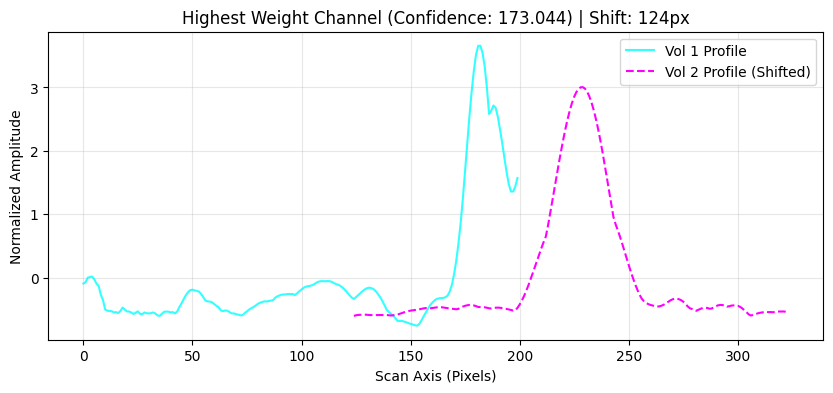

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags
from pathlib import Path
import napari

# ==========================================
# 1. WEIGHTED GRID-PROFILE TFM STITCHER
# ==========================================
class TFMStitcher:
    def __init__(self, vol1, vol2, scan_axis=2):
        self.vol1 = vol1.astype(np.float32)
        self.vol2 = vol2.astype(np.float32)
        self.axis = scan_axis
        self.shift_index = None
        self.best_profile1 = None
        self.best_profile2 = None
        self.peak_confidence = 0.0
        self.lags = None

    def find_optimal_shift(self, grid_size=(10, 10), ignore_top=30, ignore_bottom=10, expected_shift=None, tolerance=50):
        """
        Calculates shift using a Weighted Consensus approach.
        Tiles with higher correlation scores exert more influence on the final result.
        """
        z_dim, y_dim, x_dim = self.vol1.shape
        z_start, z_end = ignore_top, z_dim - ignore_bottom
        
        tile_z = (z_end - z_start) // grid_size[0]
        tile_y = y_dim // grid_size[1]
        
        all_shifts = []
        all_weights = []
        last_best_corr = -np.inf

        print(f"Applying Search Constraint: Expected {expected_shift} +/- {tolerance}")

        for r in range(grid_size[0]):
            for c in range(grid_size[1]):
                zs, ze = z_start + (r * tile_z), z_start + ((r + 1) * tile_z)
                ys, ye = c * tile_y, (c + 1) * tile_y
                
                # Extract Profiles
                prof1 = np.max(self.vol1[zs:ze, ys:ye, :], axis=(0, 1))
                prof2 = np.max(self.vol2[zs:ze, ys:ye, :], axis=(0, 1))

                # SNR Gate
                if np.std(prof1) < 1e-5 or np.max(prof1) < np.max(self.vol1) * 0.1:
                    continue

                # ZNCC Normalization
                p1_n = (prof1 - np.mean(prof1)) / (np.std(prof1) + 1e-10)
                p2_n = (prof2 - np.mean(prof2)) / (np.std(prof2) + 1e-10)
                
                corr = correlate(p1_n, p2_n, mode='full')
                self.lags = correlation_lags(len(p1_n), len(p2_n), mode='full')
                
                # Search Constraint
                if expected_shift is not None:
                    mask = (self.lags >= expected_shift - tolerance) & (self.lags <= expected_shift + tolerance)
                    if not np.any(mask): continue
                    corr[~mask] = -np.inf 

                # Find Peak and Weight
                peak_idx = np.argmax(corr)
                weight = corr[peak_idx]
                
                if weight > last_best_corr:
                    last_best_corr = weight
                    self.best_profile1 = p1_n
                    self.best_profile2 = p2_n
                    self.peak_confidence = weight

                all_shifts.append(self.lags[peak_idx])
                all_weights.append(weight)

        if not all_shifts:
            raise ValueError("No features found within the specified search range!")

        # --- WEIGHTED CONSENSUS VOTE ---
        lag_min, lag_max = np.min(self.lags), np.max(self.lags)
        bins = np.arange(lag_min, lag_max + 2) - 0.5
        
        weighted_counts, bin_edges = np.histogram(
            all_shifts, 
            bins=bins, 
            weights=all_weights
        )
        
        best_bin_idx = np.argmax(weighted_counts)
        self.shift_index = int(bin_edges[best_bin_idx] + 0.5)
        
        print(f"Weighted Consensus Shift: {self.shift_index} px")
        print(f"Participating Channels: {len(all_shifts)} | Supreme Voter Confidence: {self.peak_confidence:.3f}")
        
        return self.shift_index

    def plot_winner(self):
        """Visual verification of the highest-weight profile."""
        if self.best_profile1 is None: return
        plt.figure(figsize=(10, 4))
        plt.plot(self.best_profile1, label='Vol 1 Profile', color='cyan', alpha=0.8)
        
        shifted_x = np.arange(len(self.best_profile2)) + self.shift_index
        plt.plot(shifted_x, self.best_profile2, label='Vol 2 Profile (Shifted)', color='magenta', linestyle='--')
        
        plt.title(f"Highest Weight Channel (Confidence: {self.peak_confidence:.3f}) | Shift: {self.shift_index}px")
        plt.xlabel("Scan Axis (Pixels)")
        plt.ylabel("Normalized Amplitude")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    def stitch(self, blend_mode='linear'):
        """Stitches volumes with a linear blend over the overlap."""
        shift = int(round(self.shift_index))
        s1, s2 = self.vol1.shape, self.vol2.shape
        L1, L2 = s1[self.axis], s2[self.axis]
        
        v1_start, v2_start = (abs(shift), 0) if shift < 0 else (0, shift)
        total_len = max(v1_start + L1, v2_start + L2)
        
        out_shape = list(s1); out_shape[self.axis] = total_len
        stitched = np.zeros(out_shape, dtype=np.float32)
        
        def get_slice_idx(start, length):
            sl = [slice(None)] * 3
            sl[self.axis] = slice(int(start), int(start + length))
            return tuple(sl)

        inter_start, inter_end = max(v1_start, v2_start), min(v1_start + L1, v2_start + L2)
        overlap_len = inter_end - inter_start
        
        stitched[get_slice_idx(v1_start, L1)] = self.vol1
        
        if overlap_len > 0:
            idx1_overlap, idx2_overlap = inter_start - v1_start, inter_start - v2_start
            chunk1 = self.vol1[get_slice_idx(idx1_overlap, overlap_len)]
            chunk2 = self.vol2[get_slice_idx(idx2_overlap, overlap_len)]
            
            ramp = np.linspace(0, 1, overlap_len)
            ramp_shape = [1, 1, 1]; ramp_shape[self.axis] = overlap_len
            w2 = ramp.reshape(ramp_shape)
            if shift < 0: w2 = 1.0 - w2
            
            stitched[get_slice_idx(inter_start, overlap_len)] = (chunk1 * (1.0 - w2)) + (chunk2 * w2)
            
        post_len = (v2_start + L2) - inter_end
        if post_len > 0:
            src_start = inter_end - v2_start
            stitched[get_slice_idx(inter_end, post_len)] = self.vol2[get_slice_idx(src_start, post_len)]
            
        return stitched

# ==========================================
# 2. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # Update directory path as needed
    IN_DIR = Path.cwd().parent /'DATA' / '2D TFM Data' / 'FeC Smile 3MHz 04022026 Filtered Old'
    
    try:
        vol1_raw = np.load(IN_DIR / "FeC_40_4_filtered_3D_TFM.npy")
        vol2_raw = np.load(IN_DIR / "FeC_40_3_filtered_3D_TFM.npy")
    except FileNotFoundError:
        print("Data files not found.")
        exit()

    stitcher = TFMStitcher(vol1_raw, vol2_raw, scan_axis=2)
    
    # Grid search: (60 rows by 20 columns)
    # expected_shift and tolerance keep the math tied to physical reality
    shift = stitcher.find_optimal_shift(
        grid_size=(60, 20), 
        ignore_top=15, 
        ignore_bottom=0,
        expected_shift=0,  
        tolerance=200       
    )
    
    stitcher.plot_winner() 
    result = stitcher.stitch(blend_mode='linear')

    # Visual Inspection in Napari
    viewer = napari.Viewer()
    clim = [0, np.percentile(vol1_raw, 99.9)]
    
    viewer.add_image(vol1_raw, name='Vol1 (Cyan)', colormap='cyan', contrast_limits=clim)
    
    trans = [0, 0, 0]; trans[2] = shift
    viewer.add_image(vol2_raw, name='Vol2 (Magenta) [Shifted]', colormap='magenta', translate=trans, contrast_limits=clim)
    
    viewer.add_image(result, name='Weighted_Stitched_Result', contrast_limits=clim)
    napari.run()